In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Shape:", X.shape)

Selected Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Feature Shape: (768, 8)


In [6]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in potentially invalid variables:\n")

for column in invalid_columns:
    print(column, ":", (X[column] == 0).sum())

Zero values in potentially invalid variables:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [7]:
for column in invalid_columns:
    X[column] = X[column].replace(0, np.nan)

print("Missing values after replacing invalid zeros:\n")
print(X.isnull().sum())

Missing values after replacing invalid zeros:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [8]:
for column in invalid_columns:
    X[column] = X[column].fillna(X[column].median())

print("Missing values after median imputation:\n")
print(X.isnull().sum())

Missing values after median imputation:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature standardization completed successfully!")

print("\nStandardized Data Shape:", X_scaled.shape)

Feature standardization completed successfully!

Standardized Data Shape: (768, 8)


In [10]:
print("\nFirst 5 standardized observations:")
print(X_scaled[:5])


First 5 standardized observations:
[[ 0.63994726  0.86604475 -0.03198993  0.67064253 -0.18154124  0.16661938
   0.46849198  1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  -0.01230129 -0.18154124 -0.85219976
  -0.36506078 -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 -0.01230129 -0.18154124 -1.33250021
   0.60439732 -0.10558415]
 [-0.84488505 -1.07356674 -0.5283186  -0.69524511 -0.54064177 -0.63388137
  -0.92076261 -1.04154944]
 [-1.14185152  0.50442227 -2.67907616  0.67064253  0.31656594  1.5493025
   5.4849091  -0.0204964 ]]


In [11]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

print("Elbow Method calculations completed!")
print("\nInertia values:")

for k, value in zip(K_range, inertia):
    print(f"K = {k}: {value:.2f}")

c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\TANIYA VARTAK\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\TANIYA VARTAK\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\TANIYA VARTAK\anaconda3\Lib\subprocess.py", line 1538, in _execute_child


Elbow Method calculations completed!

Inertia values:
K = 2: 4975.02
K = 3: 4335.74
K = 4: 3912.70
K = 5: 3678.67
K = 6: 3474.50
K = 7: 3307.31
K = 8: 3145.46
K = 9: 2995.16
K = 10: 2892.03


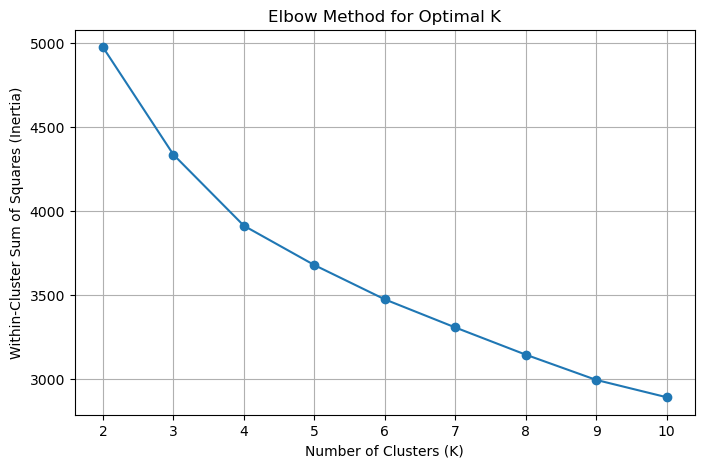

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")

plt.xticks(K_range)
plt.grid()

plt.show()

In [13]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

print("Silhouette Scores:\n")

for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}: {score:.4f}")

c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

Silhouette Scores:

K = 2: 0.1963
K = 3: 0.1950
K = 4: 0.1898
K = 5: 0.1775
K = 6: 0.1682
K = 7: 0.1226
K = 8: 0.1463
K = 9: 0.1466
K = 10: 0.1448


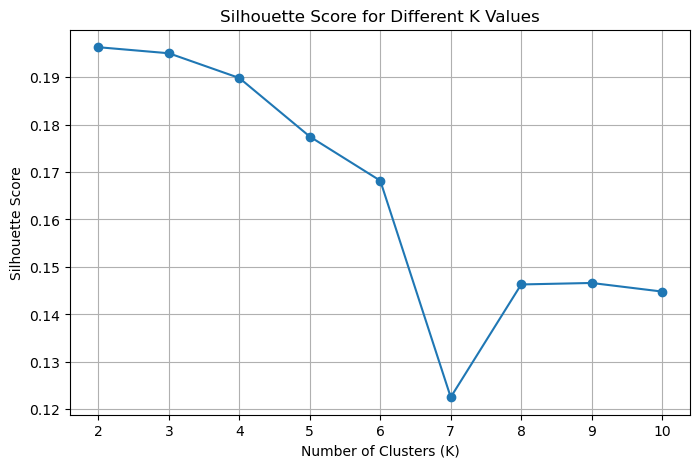

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(K_range)
plt.grid()

plt.show()

In [15]:
optimal_k = 2

print("Selected Number of Clusters:", optimal_k)

Selected Number of Clusters: 2


In [16]:
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

print("\nCluster labels:")
print(cluster_labels[:20])

K-Means clustering completed successfully!

Cluster labels:
[0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1]


c:\Users\TANIYA VARTAK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [17]:
df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

print("Cluster labels added to dataset.")

df_clustered[
    ["Glucose", "BMI", "Age", "Outcome", "Cluster"]
].head(10)

Cluster labels added to dataset.


,Glucose,BMI,Age,Outcome,Cluster
0,148,33.6,50,1,0
1,85,26.6,31,0,1
2,183,23.3,32,1,0
3,89,28.1,21,0,1
4,137,43.1,33,1,1
5,116,25.6,30,0,1
6,78,31.0,26,1,1
7,115,35.3,29,0,0
8,197,30.5,53,1,0
9,125,0.0,54,1,0


In [18]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

print("Number of observations in each cluster:\n")
print(cluster_counts)

Number of observations in each cluster:

Cluster
0    351
1    417
Name: count, dtype: int64


In [19]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final K-Means Clustering")
print("------------------------")
print("Number of Clusters:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))

Final K-Means Clustering
------------------------
Number of Clusters: 2
Silhouette Score: 0.1963


In [20]:
cluster_outcome_table = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["Outcome"]
)

cluster_outcome_table.columns = [
    "Non-Diabetic",
    "Diabetic"
]

print("Cluster vs Outcome:")
print(cluster_outcome_table)

Cluster vs Outcome:
         Non-Diabetic  Diabetic
Cluster                        
0                 156       195
1                 344        73


In [21]:
cluster_profile = df_clustered.groupby("Cluster")[features].mean()

print("Cluster Profiles:")
display(cluster_profile.round(2))

Cluster Profiles:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,5.78,137.25,76.78,22.66,100.12,35.05,0.51,41.12
1,2.22,107.13,62.65,18.75,62.70,29.42,0.44,26.61


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Original number of features:", X_scaled.shape[1])
print("Reduced number of dimensions:", X_pca.shape[1])

PCA completed successfully!
Original number of features: 8
Reduced number of dimensions: 2


In [23]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print("PC1:", round(explained_variance[0], 4))
print("PC2:", round(explained_variance[1], 4))

print(
    "\nTotal Variance Explained by PC1 and PC2:",
    round(explained_variance.sum(), 4)
)

print(
    "Total Variance Explained (%):",
    round(explained_variance.sum() * 100, 2),
    "%"
)

Explained Variance Ratio:
PC1: 0.2854
PC2: 0.1869

Total Variance Explained by PC1 and PC2: 0.4723
Total Variance Explained (%): 47.23 %


In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels
pca_df["Outcome"] = df["Outcome"].values

print("PCA DataFrame:")
display(pca_df.head())

PCA DataFrame:


,PC1,PC2,Cluster,Outcome
0,1.449481,0.659769,0,1
1,-1.498835,-0.076049,1,0
2,0.423246,0.761327,0,1
3,-2.152468,-0.166717,1,0
4,0.697836,-3.548952,1,1


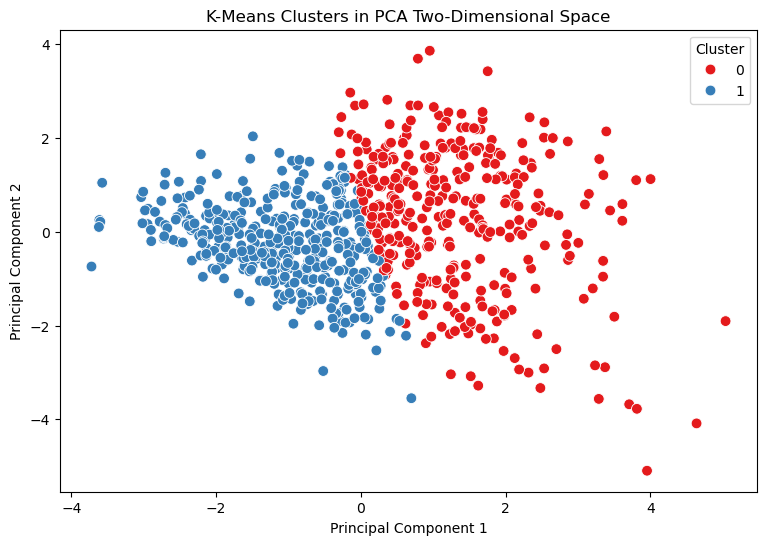

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("K-Means Clusters in PCA Two-Dimensional Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

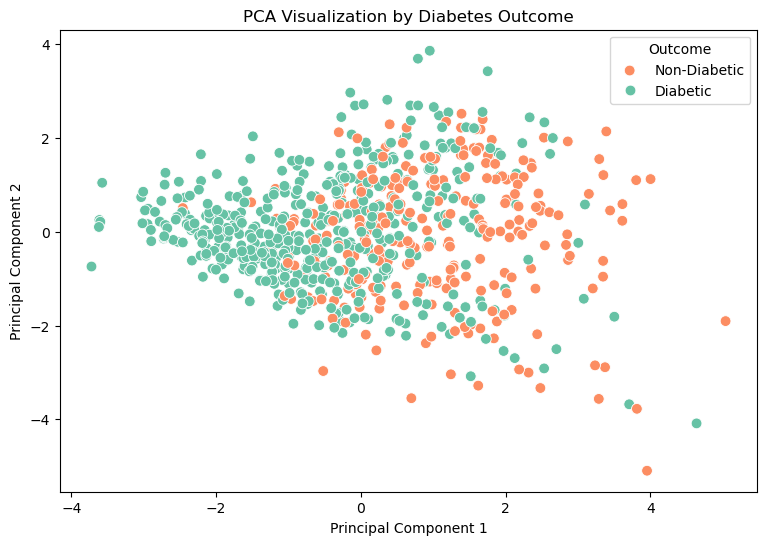

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="Set2",
    s=60
)

plt.title("PCA Visualization by Diabetes Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Outcome",
    labels=["Non-Diabetic", "Diabetic"]
)

plt.show()